In [2]:
using Random, Revise
using CairoMakie
using LinearAlgebra
using StatsBase
using LaTeXStrings
using DifferentialEquations
using JLD2
includet("Utils.jl")
includet("DMFT.jl")
includet("FigureStyles.jl")
using .Utils
using .FigureStyles
using .DMFT

# Phase diagram for positive $\tau^\mathrm{chn}$ and $J_0=-5$

In [3]:
# Run PosChnNumericalPhaseDiagram.jl
data = load("./results/PostauChn_g_PhaseDiagram.jld2");
τ_chn_vec = data["τ_chn_vec"]
g_vec = data["g_vec"]
N = data["N"]
J0 = data["J0"]
phase_matrix = data["phase_matrix"];

In [4]:
function BulkOutlierBoundary(du, g, p)
    τc, N, J0 = p
    g = g[1]
    du .= real(1 / 2 * (J0 * N + sqrt(Complex(J0^2 * N^2 + 4g^2 * (N - 1) * τc)))) - (1 - 4τc) / sqrt(1 - 2τc) * g
end

function OutlierStableBoundary(du, g, p)
    τc, N, J0 = p
    g = g[1]
    du .= real(1 / 2 * (J0 * N + sqrt(Complex(J0^2 * N^2 + 4g^2 * (N - 1) * τc)))) - 1
end

boundary_τc = τ_chn_vec[1]:0.0001:τ_chn_vec[end]
bulk_outlier_g_boundary = zeros(length(boundary_τc))
for (i, τc) in enumerate(boundary_τc)
    params = (τc, N, J0)
    prob = NonlinearProblem(BulkOutlierBoundary, [10.0], params)
    sol = solve(prob)
    if SciMLBase.successful_retcode(sol) && sol.u[1] > 1e-5
        bulk_outlier_g_boundary[i] = sol.u[1]
    else
        bulk_outlier_g_boundary[i] = NaN
    end
end


bulk_stability_boundary = sqrt.(1.0 .- 2.0 .* boundary_τc) ./ (1.0 .- 4 .* boundary_τc)
outlier_g_boundary = sqrt.((1.0 - J0 * N) ./ (boundary_τc .* (N - 1)))
distance = abs.(outlier_g_boundary .- bulk_outlier_g_boundary)
valid_idx = findall(@. !isnan(distance))
critical_idx = argmin(distance[valid_idx])
boundary_intersect = valid_idx[critical_idx]
@. outlier_g_boundary[1:boundary_intersect-1] = NaN
@. bulk_stability_boundary[boundary_intersect+1:end] = NaN
@. bulk_outlier_g_boundary[boundary_intersect+1:end] = NaN;

In [5]:
# Run PosChnHCSCBoundary.jl
HCSCData = load("results/PosChnHCSCBoundaryN2000J0-5p0B0.jld2")
HCSC_g_vec = HCSCData["g_vec"]
HSCS_τchn_vec = HCSCData["τchn_boundary"];

# Run PosChnSCFPBoundary.jl
SCFPData = load("results/PosChnSCFPBoundaryN2000J0-5p0B0.jld2")
SCFP_g_vec = SCFPData["g_vec"]
SCFP_τchn_vec = SCFPData["τchn_boundary"];
SCFP_g_vec = vcat(outlier_g_boundary[boundary_intersect], SCFP_g_vec)
SCFP_τchn_vec = vcat(boundary_τc[boundary_intersect], SCFP_τchn_vec);

### Visualize some trajectories

In [7]:
N = 2000
Random.seed!(123)
J0 = -5.0 / N
x0 = randn(N) * 0.8 .+ 0.2
tspan = (0.0, 50.0)
saveat = 0.2

trajectory_params = [
    (g = 0.85, τchn = 5.0 / N),
    (g = 2.5, τchn = 2.5 / N),
    (g = 2.5, τchn = 7.5 / N),
    (g = 2.5, τchn = 5.2 / N),
]
output_file = "results/PosChnExamplesN$(N)J0$(parameter_token(N * J0))B0.jld2"

if isfile(output_file)
    example_data = load(output_file)
    examples = example_data["examples"]
    N = example_data["N"]
    J0 = example_data["J0"]
    x0 = example_data["x0"]
    tspan = example_data["tspan"]
    saveat = example_data["saveat"]
    trajectory_params = example_data["trajectory_params"]
    sims = [(sol = (t = example.t,), X = example.X, eigenvalues = example.eigenvalues, τchn = example.τchn, g = example.g) for example in examples]
else
    sims = []
    for p in trajectory_params
        J = CreateJ(N, J0, p.g, (p.τchn, 0.0))
        eigenvalues = eigvals(J)
        prob = ODEProblem(GaussianTanh!, x0, tspan, J)
        sol = solve(prob, Tsit5(), saveat=saveat)
        X = Array(sol)'
        push!(sims, (sol = sol, X = X, eigenvalues = eigenvalues, τchn = p.τchn, g = p.g))
    end

    examples = [(t = sim.sol.t, X = sim.X, eigenvalues = sim.eigenvalues, τchn = sim.τchn, g = sim.g) for sim in sims]
    jldsave(output_file; examples, N, J0, x0, tspan, saveat, trajectory_params)
end

4-element Vector{@NamedTuple{sol::@NamedTuple{t::Vector{Float64}}, X::Adjoint{Float64, Matrix{Float64}}, eigenvalues::Vector{ComplexF64}, τchn::Float64, g::Float64}}:
 (sol = (t = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8  …  48.2, 48.4, 48.6, 48.8, 49.0, 49.2, 49.4, 49.6, 49.8, 50.0],), X = [0.8466303427719735 -0.6976580064913387 … 0.19193071453166663 -0.6103491039779754; 0.5852519217565227 -0.5571390025716308 … 0.12962691909508217 -0.527979937507574; … ; -3.350515632880838e-5 -1.2744293512462277e-5 … -1.0975845447107213e-5 -3.1943618947938254e-5; -3.2279357058896285e-5 -1.2087868855744477e-5 … -1.0853326644999795e-5 -2.979266197925788e-5], eigenvalues = [-5.504459197611673 + 0.0im, -0.8448037651557955 - 0.06501958298379391im, -0.8448037651557955 + 0.06501958298379391im, -0.8346940537121073 - 0.11778433333927268im, -0.8346940537121073 + 0.11778433333927268im, -0.8346774775415485 + 0.0im, -0.8256559500034198 - 0.028148928280144477im, -0.8256559500034198 + 0.028148928280144477im

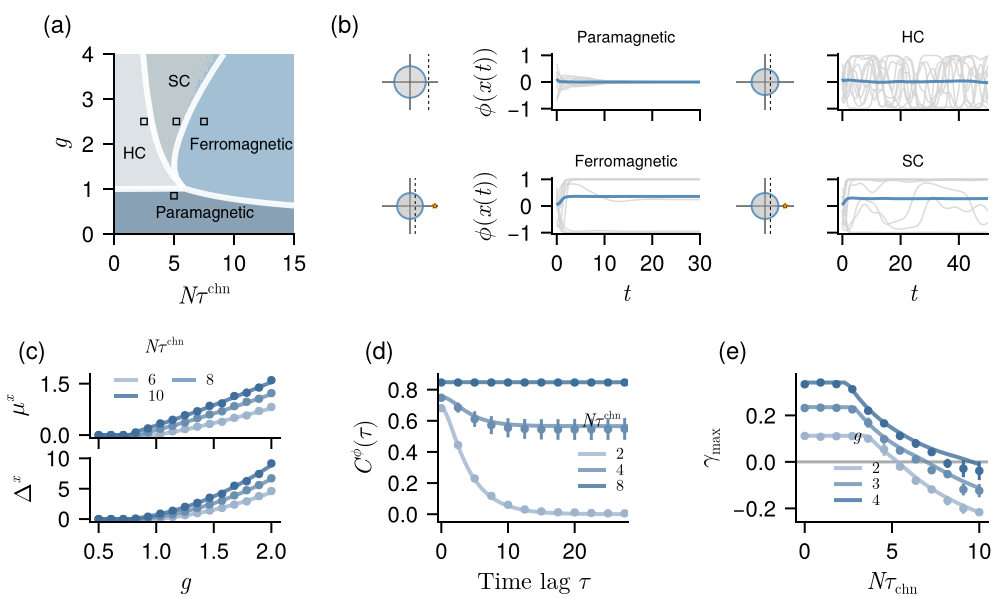

CairoMakie.Screen{IMAGE}


In [10]:
set_theme!(DoubleColumnTheme)
f1 = Figure(size=(7.0 * 72, 4.15 * 72), figure_padding=(2, 10, 2, 5))
phase_diagram_grid = f1[1, 1] = GridLayout()
phase_diagram_ax = Axis(phase_diagram_grid[1, 1],
    xlabel=L"$N\tau^{\mathrm{chn}}$",
    ylabel=L"$g$",
    limits=(0.0, 15.0, 0.0, 4.0),
    xticks=[0.0, 5, 10, 15],
    aspect = 1
)
hm = heatmap!(phase_diagram_ax, N * τ_chn_vec, g_vec, transpose(phase_matrix); colormap=cgrad(phase_colors[2:5], 4, categorical=true), alpha=1.0)
lines!(phase_diagram_ax, N * boundary_τc, bulk_stability_boundary, linewidth=3, color=:white, alpha=0.9) # zero fp to homogeneous chaos
lines!(phase_diagram_ax, N * HSCS_τchn_vec, HCSC_g_vec; linewidth=3, color=:white, alpha=0.9)
lines!(phase_diagram_ax, N * boundary_τc, outlier_g_boundary, linewidth=3, color=:white, alpha=0.9) # zero fp to nonzero fp
lines!(phase_diagram_ax, N * SCFP_τchn_vec, SCFP_g_vec, linewidth=3, color=:white, alpha=0.9)
text!(phase_diagram_ax, 0.42, 0.45; text="Ferromagnetic", space=:relative, fontsize=8)
text!(phase_diagram_ax, 0.23, 0.07; text="Paramagnetic", space=:relative, fontsize=8)
text!(phase_diagram_ax, 0.05, 0.4; text="HC", space=:relative, fontsize=8)
text!(phase_diagram_ax, 0.3, 0.8; text="SC", space=:relative, fontsize=8)
Label(phase_diagram_grid[1, 1, TopLeft()], "(a)", fontsize=12, padding=(0f0, 0f0, 8f0, 0f0));

trajectory_grid = phase_diagram_grid[1, 2] = GridLayout()
bulk_boundary_angles = range(0, 2π, length=100)
trajectory_regime_titles = ["Paramagnetic", "HC", "Ferromagnetic", "SC"]
scatter!(phase_diagram_ax, [N * sim.τchn for sim in sims], [sim.g for sim in sims];
    marker=:rect, markersize=5, color=phase_colors[2:5], strokecolor=:black, strokewidth=0.7)

function displayed_eigenspectrum(sim)
    τ = (sim.τchn, 0.0)
    theory_outliers = collect(TheoryOutlier(N, J0, sim.g, τ))
    theory_outlier = [theory_outliers[argmax(real.(theory_outliers))]]
    outlier_idx = findall(abs.(sim.eigenvalues) .> sim.g * 1.1)
    positive_outlier_idx = outlier_idx[real.(sim.eigenvalues[outlier_idx]) .> 0]
    largest_outlier_idx = isempty(positive_outlier_idx) ? nothing : positive_outlier_idx[argmax(real.(sim.eigenvalues[positive_outlier_idx]))]
    outlier = isnothing(largest_outlier_idx) ? ComplexF64[] : [sim.eigenvalues[largest_outlier_idx]]
    bulk = sim.eigenvalues[abs.(sim.eigenvalues) .<= sim.g * 1.1]
    return (τ=τ, bulk=bulk, outlier=outlier, theory_outlier=theory_outlier)
end

displayed_eigenspectra = [displayed_eigenspectrum(sim) for sim in sims]
all_displayed_eigenvalues = vcat([vcat(eig.bulk, eig.outlier, eig.theory_outlier) for eig in displayed_eigenspectra]...)
eigen_extent = 1.12 * maximum(abs.(vcat(real.(all_displayed_eigenvalues), imag.(all_displayed_eigenvalues), 1.0)))
eigen_limits = (-eigen_extent, eigen_extent, -eigen_extent, eigen_extent)

for (j, sim) in enumerate(sims)
    original_row = div(j - 1, 2) + 1
    original_col = mod(j - 1, 2) + 1
    row = original_row
    eigen_col = 3 * (original_col - 1) + 1
    traj_cols = (eigen_col + 1):(eigen_col + 2)

    eig = displayed_eigenspectra[j]
    ax_eigen = Axis(trajectory_grid[row, eigen_col], aspect=1, limits=eigen_limits)
    if row == 1 && eigen_col == 1
        ax_eigen.limits = (-1.5, 1.5, -1.5, 1.5)
    end
    hidespines!(ax_eigen)
    hidedecorations!(ax_eigen)
    hlines!(ax_eigen, 0; color=:black, linewidth=0.5)
    vlines!(ax_eigen, 0; color=:black, linewidth=0.5)

    scatter!(ax_eigen, real.(eig.bulk), imag.(eig.bulk); color=:gray70, markersize=0.7, alpha=0.3, rasterize=30)
    scatter!(ax_eigen, real.(eig.outlier), imag.(eig.outlier); color=:orange, markersize=4.0, alpha=0.7)
    theory_R = TheoryR(sim.g, eig.τ)
    lines!(ax_eigen, theory_R .* cos.(bulk_boundary_angles), theory_R .* sin.(bulk_boundary_angles); color=:steelblue, linewidth=1.0, alpha=0.8)
    vlines!(ax_eigen, 1; color=:black, linewidth=0.5, linestyle=:dash)
    if maximum(real.(eig.theory_outlier)) > theory_R
        scatter!(ax_eigen, real.(eig.theory_outlier), imag.(eig.theory_outlier); marker=:star5, markersize=3.0, color=:orange, strokecolor=:black, strokewidth=0.2, alpha=0.8)
    end
    ax = Axis(trajectory_grid[row, traj_cols], yticks=[-1.0, 0.0, 1.0],
        title=trajectory_regime_titles[j], titlesize=8, titlefont=:regular)
    if original_col == 1
        ax.ylabel = L"\phi(x(t))"
        ax.limits = (-1.0, 30, -1.05, 1.05)
    else
        ax.yticklabelsvisible = false
        ax.limits = (-1.5, 50, -1.05, 1.05)
    end
    if original_row == 2
        ax.xlabel = L"t"
    else
        ax.xticklabelsvisible = false
    end
    for i in 1:10
        lines!(ax, sim.sol.t, tanh.(sim.X[:, i]); linewidth=0.8, color=:lightgray, alpha=0.8)
    end
    lines!(ax, sim.sol.t, vec(mean(tanh.(sim.X), dims=2)); color=:steelblue, linewidth=1.5, alpha=0.9)
end

rowgap!(trajectory_grid, 15)
colgap!(trajectory_grid, 12)
colsize!(phase_diagram_grid, 1, 1.6*72)
colgap!(phase_diagram_grid, 5)
colsize!(trajectory_grid, 1, 40)
colsize!(trajectory_grid, 4, 40)

Label(trajectory_grid[1, 1, TopLeft()], "(b)", fontsize=12, padding=(0f0, 5f0, 8f0, 0f0));

# Run DMFTFP2FP.jl
fp_data = load("results/FP2FPgSweep.jld2")
g_vec_num_fp = Float64.(collect(fp_data["g_vec_num"]))
g_vec_dmft_fp = Float64.(collect(fp_data["g_vec_dmft"]))
τchn_vec_fp = Float64.(collect(fp_data["τchn_vec"]))
N_fp = fp_data["N"]
μ_num_fp = fp_data["μ_num"]
Δ_num_fp = fp_data["Δ_num"]
μ_num_std_fp = fp_data["μ_num_std"]
Δ_num_std_fp = fp_data["Δ_num_std"]
μ_dmft_fp = fp_data["μ_dmft"]
Δ_dmft_fp = fp_data["Δ_dmft"]
linewidth = 2.0
cmap = to_colormap(:cork25)
fp_colors = cmap[[10, 8, 6]]
dmft_grid = f1[2, 1] = GridLayout()
fp_grid = dmft_grid[1, 1] = GridLayout()
ax_fp_mean = Axis(fp_grid[1, 1];
    ylabel = L"\mu^x", xticks=[0.5, 1.0, 1.5, 2.0], 
    xticklabelsvisible=false,
    yticks=[0.0, 1.5])
ax_fp_var = Axis(fp_grid[2, 1];
    xlabel = L"g",
    ylabel = L"\Delta^x",
    xticks = [0.5, 1.0, 1.5, 2.0])

for (j, τchn) in enumerate(τchn_vec_fp)
    color = fp_colors[j]
    legend_label = L"%$(Int64(N_fp * τchn))"

    μ_theo = vec(μ_dmft_fp[j, :])
    valid_μ_theo = .!isnan.(μ_theo)
    lines!(ax_fp_mean, g_vec_dmft_fp[valid_μ_theo], abs.(μ_theo[valid_μ_theo]);
        color = color, linewidth = linewidth, alpha = 0.8, label = legend_label)

    μ_num = vec(μ_num_fp[j, :])
    μ_std = vec(μ_num_std_fp[j, :])
    valid_μ_num = .!isnan.(μ_num) .& .!isnan.(μ_std)
    errorbars!(ax_fp_mean, g_vec_num_fp[valid_μ_num], μ_num[valid_μ_num], μ_std[valid_μ_num];
        color = color, linewidth = 1.0, whiskerwidth = 0)
    scatter!(ax_fp_mean, g_vec_num_fp[valid_μ_num], μ_num[valid_μ_num];
        color = color, marker = :circle, markersize = 6)

    Δ_theo = vec(Δ_dmft_fp[j, :])
    valid_Δ_theo = .!isnan.(Δ_theo)
    lines!(ax_fp_var, g_vec_dmft_fp[valid_Δ_theo], Δ_theo[valid_Δ_theo];
        color = color, linewidth = linewidth, alpha = 0.8)

    Δ_num = vec(Δ_num_fp[j, :])
    Δ_std = vec(Δ_num_std_fp[j, :])
    valid_Δ_num = .!isnan.(Δ_num) .& .!isnan.(Δ_std)
    errorbars!(ax_fp_var, g_vec_num_fp[valid_Δ_num], Δ_num[valid_Δ_num], Δ_std[valid_Δ_num];
        color = color, linewidth = 1.0, whiskerwidth = 0)
    scatter!(ax_fp_var, g_vec_num_fp[valid_Δ_num], Δ_num[valid_Δ_num];
        color = color, marker = :circle, markersize = 6)
end

linkxaxes!(ax_fp_mean, ax_fp_var)
axislegend(ax_fp_mean, L"N\tau^{\mathrm{chn}}"; framevisible=false, titlesize=9, 
    nbanks=2, patchsize=(12, 4), rowgap=0.0, colgap=4.0, position=(0.0, -0.2))
rowgap!(fp_grid, 5)
Label(fp_grid[1, 1, TopLeft()], "(c)", fontsize = 12, padding = (0f0, 15f0, 5f0, 0f0));

# Run DMFTB0PosChnComparison.jl
data = load("results/DMFTB0CompPositivetauChn.jld2")
results = data["results"]
τchn_vec = data["τchn_vec"]
N = data["N"]
ax = Axis(dmft_grid[1, 2],  xlabel=L"\text{Time lag } τ",
    ylabel=L"C^{\phi}(τ)",
    limits=(-0.5, 28.0, -0.05, nothing))
for (i, τchn) in enumerate(τchn_vec)
    num = results[i].NumericalResult
    numerical_idx = 1:5:length(num.times)
    dmft = results[i].DMFTResult
    Cϕ_num = num.Cϕ_mean[numerical_idx]
    scatter!(ax, num.times[numerical_idx], Cϕ_num, color=fp_colors[i], markersize=6)
    lower = num.Cϕ_std[numerical_idx]
    upper = num.Cϕ_std[numerical_idx]
    errorbars!(ax, num.times[numerical_idx], Cϕ_num, lower, upper, color=fp_colors[i], linewidth=1.5)
    Cϕ_dmft = dmft.Cϕ
    lines!(ax, dmft.times, dmft.Cϕ; color=fp_colors[i], linewidth=2.0, alpha=0.8, label=L"%$(Int64(N*τchn))")
end

axislegend(ax, L"N\tau^{\mathrm{chn}}"; framevisible = false, 
    patchsize = (14, 8), rowgap = 0.0, position=(1.2, 0.24), titlesize=9)
Label(dmft_grid[1, 2, TopLeft()], "(d)", fontsize=12, padding=(0f0, 15f0, 5f0, 0f0));


# Run LLENumericalVSTheoretical.jl
lle_data = load("results/LLENumericalVSTheoretical.jld2")
g_vals = Float64.(lle_data["g_vec"])
N_lle = lle_data["N"]
τ_chn_vec_num = collect(lle_data["τ_chn_vec_num"])
τ_chn_vec_theo = collect(lle_data["τ_chn_vec_theo"])
LLE_mean_num = lle_data["LLE_mean_num"]
LLE_std_num = lle_data["LLE_std_num"]
LLE_mean_theo = lle_data["LLE_mean_theo"]

x_num = N_lle .* τ_chn_vec_num
x_theo = N_lle .* τ_chn_vec_theo

cmap = to_colormap(:cork25)
g_colors = cmap[[10, 8, 6]]

ax_lle_compare = Axis(dmft_grid[1, 3];
    xlabel = L"N\tau_{\mathrm{chn}}",
    ylabel = L"\gamma_{\max}")
hlines!(ax_lle_compare, 0.0; color = (:gray40, 0.55), linewidth = 1.5)
for (ig, g) in enumerate(g_vals)
    color = g_colors[ig]

    y_theo = vec(LLE_mean_theo[ig, :])
    valid_theo = .!isnan.(y_theo)
    lines!(ax_lle_compare, x_theo[valid_theo], y_theo[valid_theo];
        color = color, linewidth = 2.0, alpha=0.8, label = L"%$(Int64(g))")

    y_num = vec(LLE_mean_num[ig, :])
    y_std = vec(LLE_std_num[ig, :])
    valid_num = .!isnan.(y_num) .& .!isnan.(y_std)
    errorbars!(ax_lle_compare, x_num[valid_num], y_num[valid_num], y_std[valid_num];
        color = color, linewidth=1.5, whiskerwidth = 0)
    scatter!(ax_lle_compare, x_num[valid_num], y_num[valid_num];
        color = color, marker = :circle, markersize = 6)
end


axislegend(ax_lle_compare, L"g"; titlesize=9, position = (0.14, -.6), framevisible = false, 
    patchsize=(14, 5), rowgap=0.0)
rowsize!(f1.layout, 1, 90)
rowgap!(f1.layout, 15)
colgap!(dmft_grid, 35)
Label(dmft_grid[1, 3, TopLeft()], "(e)", fontsize=12, padding=(0f0, 15f0, 5f0, 0f0))
# save("images/PhaseDiagramN2000J0-5p0.pdf", f1, pt_per_unit=1)
display(f1)


# Phase diagram for negative $\tau^{\mathrm{chn}}$ and $J_0=4$

In [4]:
N = 2000
J0 = 4.0/N
LCFP_Nτchn_vec = range(1.0, 3.0, 30)
LCFP_g_vec = sqrt.((N*J0)^2 ./ (4.0 .* LCFP_Nτchn_vec))

# Run NegChnNumericalPhaseDiagram.jl
data = load("results/NegtauChn_g_PhaseDiagram.jld2")
τ_chn_vec = data["τ_chn_vec"]
g_vec = data["g_vec"]
phase_matrix_f2 = data["phase_matrix"]
# Run NegChnSCFPBoundary.jl
data = load("results/NegChnSCFPBoundaryN2000J04p0B0.jld2")
SCFP_g_vec = data["g_boundary"]
SCFP_Nτchn_vec = data["Nτchnvec"]

# Run NegChnHCSCBoundary.jl
data = load("results/NegChnHCSCBoundaryN2000J04p0B0.jld2")
HCSC_Nτchn_vec = data["τchn_vec1"] .* N
HCSC_g_vec = data["g_boundary1"];

HCLC_Nτchn_vec = data["τchn_vec2"] .* N
HCLC_g_vec = data["g_boundary2"];

In [8]:
# Run NegChnLCShading.jl

data = load("results/NegChnLCShadingN2000J04p0B0.jld2")
Cϕ1_grid = data["Cϕ1_grid"]
Cϕ2_grid = data["Cϕ2_grid"]
dt_lc = data["dt"]
LC_PHASE_HC = 1
LC_PHASE_CHAOS = 2
LC_PHASE_LC = 3

function local_peak_indices(curve)
    return findall(i -> curve[i] > curve[i - 1] && curve[i] > curve[i + 1], 2:length(curve)-1)
end

function Cϕ_curve_features(Cϕ;
        zero_tol=0.05,
        second_peak_floor=0.25,
        first_peak_window=100,
        tail_fraction=0.1)
    isnothing(Cϕ) && return nothing
    curve = Float64.(collect(Cϕ))
    curve = curve[isfinite.(curve)]
    isempty(curve) && return nothing

    scale = maximum(abs.(curve))
    if scale <= eps(Float64)
        return (decays_to_zero=true, has_second_peak=false, nondecaying=false)
    end
    curve ./= scale

    tail_start = max(1, floor(Int, (1 - tail_fraction) * length(curve)))
    tail_abs_max = maximum(abs.(curve[tail_start:end]))
    decays_to_zero = tail_abs_max < zero_tol

    peak_idx = local_peak_indices(curve)
    second_peak_idx = peak_idx[peak_idx .> first_peak_window]
    has_second_peak = any(curve[second_peak_idx] .> second_peak_floor * curve[1])
    nondecaying = !decays_to_zero && !has_second_peak

    return (
        decays_to_zero=decays_to_zero,
        has_second_peak=has_second_peak,
        nondecaying=nondecaying,
    )
end

function classify_Cϕ_curve(Cϕ1, Cϕ2; kwargs...)
    features1 = Cϕ_curve_features(Cϕ1; kwargs...)
    features2 = Cϕ_curve_features(Cϕ2; kwargs...)
    (isnothing(features1) || isnothing(features2)) && return NaN

    Cϕ1_is_HC = features1.decays_to_zero && !features1.has_second_peak
    Cϕ2_is_HC = features2.decays_to_zero && !features2.has_second_peak

    if features1.nondecaying || features2.nondecaying
        return LC_PHASE_LC
    elseif Cϕ1_is_HC && Cϕ2_is_HC
        return LC_PHASE_HC
    elseif Cϕ1_is_HC && features2.has_second_peak
        return LC_PHASE_CHAOS
    elseif features1.has_second_peak && features2.has_second_peak
        return LC_PHASE_LC
    else
        return LC_PHASE_CHAOS
    end
end

function classify_Cϕ_grid(Cϕ1_grid, Cϕ2_grid)
    @assert size(Cϕ1_grid) == size(Cϕ2_grid)
    phase_matrix = fill(NaN, size(Cϕ1_grid))
    for I in CartesianIndices(Cϕ1_grid)
        phase_matrix[I] = classify_Cϕ_curve(Cϕ1_grid[I], Cϕ2_grid[I])
    end

    return phase_matrix
end
Nτchn_vec_lc = collect(data["Nτchn_vec"])
g_vec_lc = collect(data["g_vec"])
phase_matrix_lc = classify_Cϕ_grid(Cϕ1_grid, Cϕ2_grid);

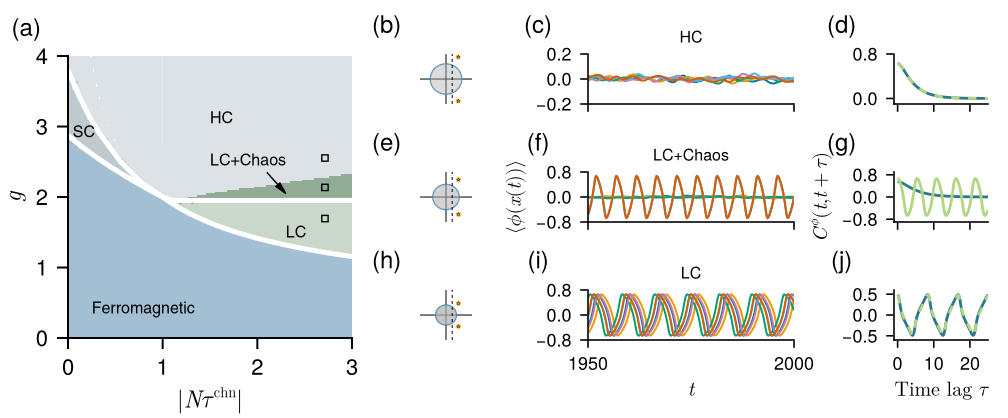

CairoMakie.Screen{IMAGE}


In [ ]:
set_theme!(DoubleColumnTheme)
f2 = Figure(size=(7.0*72, 2.9*72), figure_padding=(2, 10 ,2 ,5))
f2_grid = f2[1, 1] = GridLayout()
ax_pd = Axis(f2_grid[1:2, 1:2], xlabel=L"|N\tau^{\mathrm{chn}}|", ylabel=L"g", 
limits=(0.0, 3.0, 0.0, 4.0), aspect=1)
phase_color_matrix_f2 = map(phase_matrix_f2) do phase
    if ismissing(phase) 
        phase_colors[1]
    elseif phase == 2
        phase_colors[4]
    elseif phase == 1
        phase_colors[3]
    elseif phase == 3
        phase_colors[5]
    elseif phase == 0
        phase_colors[2]
    end
end
heatmap!(ax_pd, abs.(N .* τ_chn_vec), g_vec, transpose(phase_color_matrix_f2); alpha=1.0)
heatmap!(ax_pd, abs.(Nτchn_vec_lc), g_vec_lc, phase_matrix_lc, colormap=cgrad(phase_colors[[3, 6, 7]], 3, categorical=true))
HCLeft_Nτchn_vec = range(0.2, 1, 25)
HCLeft_glow = sqrt.((N*J0)^2 ./ (4.0 .* HCLeft_Nτchn_vec)) .- 0.04
HCLeft_ghigh = ones(length(HCLeft_Nτchn_vec)) .* 4.0
band!(ax_pd, HCLeft_Nτchn_vec, HCLeft_glow, HCLeft_ghigh; color=phase_colors[3])
HCRight_Nτchn_vec = range(1.0, 3.0, 15)
HCRight_glow = ones(length(HCRight_Nτchn_vec)) .* 2.69
HCRight_ghigh = ones(length(HCRight_Nτchn_vec)) .* 4.0
band!(ax_pd, HCRight_Nτchn_vec, HCRight_glow, HCRight_ghigh; color=phase_colors[3])
lines!(ax_pd, LCFP_Nτchn_vec, LCFP_g_vec; linewidth=2.5, color=:white)
lines!(ax_pd, abs.(SCFP_Nτchn_vec), SCFP_g_vec; linewidth=2.5, color=:white)
lines!(ax_pd, abs.(HCSC_Nτchn_vec), HCSC_g_vec; linewidth=2.5, color=:white)
lines!(ax_pd, abs.(HCLC_Nτchn_vec), HCLC_g_vec; linewidth=2.5, color=:white)
text!(ax_pd, 0.25, 0.3; text="Ferromagnetic", fontsize=8)
text!(ax_pd, 1.5, 3.0; text="HC", fontsize=8)
text!(ax_pd, 0.05, 2.8; text="SC", fontsize=8)
text!(ax_pd, 1.5, 2.4; text="LC+Chaos", fontsize=8)
arrows2d!(ax_pd, [2.1], [2.35], [0.2], [-0.3]; color = :black, align=:tail, shaftwidth=0.7, tiplength=7.0, 
tipwidth=4.0) 
text!(ax_pd, 2.3, 1.38; text="LC", fontsize=8)
scatter!(ax_pd, abs.(Nτchn_vec_lc[55]), g_vec_lc[58]; marker = :rect, markersize = 5, color = phase_colors[3], strokecolor = :black, strokewidth = 0.7)
scatter!(ax_pd, abs.(Nτchn_vec_lc[55]), g_vec_lc[23]; marker = :rect, markersize = 5, color = phase_colors[7], strokecolor = :black, strokewidth = 0.7)
scatter!(ax_pd, abs.(Nτchn_vec_lc[55]), g_vec_lc[41]; marker = :rect, markersize = 5, color = phase_colors[6], strokecolor = :black, strokewidth = 0.7)
# println("LC example parameters: g = $(g_vec_lc[23]), Nτchn = $(Nτchn_vec_lc[55])")
# println("LC+Chaos example parameters: g = $(g_vec_lc[58]), Nτchn = $(Nτchn_vec_lc[55])")
# println("HC example parameters: g = $(g_vec_lc[41]), Nτchn = $(Nτchn_vec_lc[55])")
Label(f2_grid[1, 1, TopLeft()], "(a)", fontsize=12, padding=(0f0, 10f0, 5f0, 0f0));

example_data = load("results/NegChnExamplesN4000J04p0B0.jld2")
examples = example_data["examples"]
N_example = example_data["N"]
J0_example = example_data["J0"]
τ_example = example_data["τ"]

C1_color, C2_color = cgrad(:navia, 12, categorical=true)[[5, 10]]
Δt = (0:length(Cϕ1_grid[55, 23])-1) .* dt_lc
bulk_boundary_angles = range(0, 2π, length=100)
example_grid = f2_grid[1:2, 3:6] = GridLayout()
eigen_limits = (-4.2, 4.2, -4.2, 4.2)
ax_eigen1 = Axis(example_grid[1, 1], aspect=1, limits=eigen_limits)
hidespines!(ax_eigen1)
hidedecorations!(ax_eigen1)
hlines!(ax_eigen1, 0; color = :black, linewidth = 0.5)
vlines!(ax_eigen1, 0; color = :black, linewidth = 0.5)
example1 = examples[3]
outliers = example1.eigenvalues[abs.(example1.eigenvalues) .> example1.g*1.1]
bulk = example1.eigenvalues[abs.(example1.eigenvalues) .< abs(outliers[1])]
scatter!(ax_eigen1, real.(bulk), imag.(bulk); color=:gray70, markersize=0.5, alpha=0.3, rasterize=30)
scatter!(ax_eigen1, real.(outliers), imag.(outliers); color=:orange, markersize=3.5, alpha=0.7)
theory_R = TheoryR(example1.g, τ_example)
lines!(ax_eigen1, theory_R .* cos.(bulk_boundary_angles), theory_R .* sin.(bulk_boundary_angles); color=:steelblue, linewidth=0.65, alpha=0.8)
theory_outliers = collect(TheoryOutlier(N_example, J0_example, example1.g, τ_example))
scatter!(ax_eigen1, real.(theory_outliers), imag.(theory_outliers); marker=:star5, markersize=2, color=:orange, strokecolor=:black, strokewidth=0.2, alpha=0.8)
vlines!(ax_eigen1, 1; color=:black, linewidth=0.5, linestyle=:dash)

ax_traj1 = Axis(example_grid[1, 2:5], limits=(1950, 2000, -0.2, 0.2), yticks=[-0.2, 0.0, 0.2], xticks=[1950, 2000],
    xticklabelsvisible=false, title="HC", titlesize=8, titlefont=:regular)

for i in 1:6
    lines!(ax_traj1, example1.t, example1.mean_ϕ[:, i]; linewidth=1.0)
end
ax_Cϕ1 = Axis(example_grid[1, 6:7], limits=(-1.0, 25.0, -0.1, 0.8), 
    yticks = [0.0, 0.8], xticks = [0.0, 10.0, 20.0], xticklabelsvisible=false)
lines!(ax_Cϕ1, Δt, Cϕ1_grid[55, 58]; color = C1_color, linewidth=1.4)
lines!(ax_Cϕ1, Δt, Cϕ2_grid[55, 58]; color = C2_color, linewidth=1.4, linestyle=:dash)

ax_eigen2 = Axis(example_grid[2, 1], aspect=1, limits=eigen_limits)
hidespines!(ax_eigen2)
hidedecorations!(ax_eigen2)
hlines!(ax_eigen2, 0; color = :black, linewidth = 0.5)
vlines!(ax_eigen2, 0; color = :black, linewidth = 0.5)
example2 = examples[2]
outliers = example2.eigenvalues[abs.(example2.eigenvalues) .> example2.g*1.1]
bulk = example2.eigenvalues[abs.(example2.eigenvalues) .< abs(outliers[1])]
scatter!(ax_eigen2, real.(bulk), imag.(bulk); color=:gray70, markersize=0.5, alpha=0.3, rasterize=30)
scatter!(ax_eigen2, real.(outliers), imag.(outliers); color=:orange, markersize=3.5, alpha=0.7)
theory_R = TheoryR(example2.g, τ_example)
lines!(ax_eigen2, theory_R .* cos.(bulk_boundary_angles), theory_R .* sin.(bulk_boundary_angles); color=:steelblue, linewidth=0.65, alpha=0.8)
theory_outliers = collect(TheoryOutlier(N_example, J0_example, example2.g, τ_example))
scatter!(ax_eigen2, real.(theory_outliers), imag.(theory_outliers); marker=:star5, markersize=2, color=:orange, strokecolor=:black, strokewidth=0.2, alpha=0.8)
vlines!(ax_eigen2, 1; color=:black, linewidth=0.5, linestyle=:dash)

ax_traj2 = Axis(example_grid[2, 2:5], ylabel=L"\langle \phi(x(t))\rangle", 
    limits=(1950, 2000, -0.8, 0.8), yticks=[-0.8, 0.0, 0.8], ylabelsize=10, xticks=[1950, 2000],
    xticklabelsvisible=false, title="LC+Chaos", titlesize=8, titlefont=:regular)
for i in [1, 2, 3, 7, 8, 12]
    lines!(ax_traj2, example2.t, example2.mean_ϕ[:, i]; linewidth=1.0)
end

ax_Cϕ2 = Axis(example_grid[2, 6:7], ylabel=L"C^\phi(t,t+\tau)", limits=(-1.0, 25.0, -0.9, 0.9), 
    yticks = [-0.8, 0.0, 0.8], xticks = [0.0, 10.0, 20.0], xticklabelsvisible=false, ylabelsize=10)
lines!(ax_Cϕ2, Δt, Cϕ1_grid[55, 41]; color = C1_color, linewidth=1.4)
lines!(ax_Cϕ2, Δt, Cϕ2_grid[55, 41]; color = C2_color, linewidth=1.4)

ax_eigen3 = Axis(example_grid[3, 1], aspect=1, limits=eigen_limits)
hidespines!(ax_eigen3)
hidedecorations!(ax_eigen3)
hlines!(ax_eigen3, 0; color = :black, linewidth = 0.5)
vlines!(ax_eigen3, 0; color = :black, linewidth = 0.5)

example3 = examples[1]
outliers = example3.eigenvalues[abs.(example3.eigenvalues) .> example3.g*1.1]
bulk = example3.eigenvalues[abs.(example3.eigenvalues) .< abs(outliers[1])]
scatter!(ax_eigen3, real.(bulk), imag.(bulk); color=:gray70, markersize=0.5, alpha=0.3, rasterize=30)
scatter!(ax_eigen3, real.(outliers), imag.(outliers); color=:orange, markersize=3.5, alpha=0.7)
theory_R = TheoryR(example3.g, τ_example)
lines!(ax_eigen3, theory_R .* cos.(bulk_boundary_angles), theory_R .* sin.(bulk_boundary_angles); color=:steelblue, linewidth=0.65, alpha=0.8)
theory_outliers = collect(TheoryOutlier(N_example, J0_example, example3.g, τ_example))
scatter!(ax_eigen3, real.(theory_outliers), imag.(theory_outliers); marker=:star5, markersize=2, color=:orange, strokecolor=:black, strokewidth=0.2, alpha=0.8)
vlines!(ax_eigen3, 1; color=:black, linewidth=0.5, linestyle=:dash)
ax_traj3 = Axis(example_grid[3, 2:5], xlabel=L"t", limits=(1950, 2000, -0.8, 0.8), 
     yticks = [-0.8, 0.0, 0.8], xlabelsize=10, xticks=[1950, 2000], title="LC", titlesize=8, titlefont=:regular)
for i in 1:6
    lines!(ax_traj3, example3.t, example3.mean_ϕ[:, i]; linewidth=1.0)
end
ax_Cϕ3 = Axis(example_grid[3, 6:7],  
    xlabel=L"\text{Time lag }\tau", limits=(-1.0, 25.0, -0.6, 0.6), 
    yticks = [-0.5, 0.0, 0.5], xticks = [0.0, 10.0, 20.0], xlabelsize=10)

for ax in (ax_eigen1, ax_eigen2, ax_eigen3, ax_Cϕ1, ax_Cϕ2, ax_Cϕ3, ax_traj1, ax_traj2, ax_traj3)
    ax.spinewidth = 0.8
    ax.xtickwidth = 0.8
    ax.ytickwidth = 0.8
    ax.xticklabelsize = 9
    ax.yticklabelsize = 9
end

for ax in (ax_Cϕ1, ax_Cϕ2, ax_Cϕ3, ax_traj1, ax_traj2, ax_traj3)
    ax.xticksize = 3.5
    ax.yticksize = 3.5
end

lines!(ax_Cϕ3, Δt, Cϕ1_grid[55, 23]; color = C1_color, linewidth=1.4)
lines!(ax_Cϕ3, Δt, Cϕ2_grid[55, 23]; color = C2_color, linewidth=1.4, linestyle=:dash)

padding=(0f0, 10f0, 8f0, 0f0)
Label(example_grid[1, 1, TopLeft()], "(b)", fontsize=12, padding=(0f0, 0f0, 8f0, 0f0))
Label(example_grid[1, 2, TopLeft()], "(c)", fontsize=12, padding=padding)
Label(example_grid[1, 6, TopLeft()], "(d)", fontsize=12, padding=padding)
Label(example_grid[2, 1, TopLeft()], "(e)", fontsize=12, padding=(0f0, 0f0, 8f0, 0f0))
Label(example_grid[2, 2, TopLeft()], "(f)", fontsize=12, padding=padding)
Label(example_grid[2, 6, TopLeft()], "(g)", fontsize=12, padding=padding)
Label(example_grid[3, 1, TopLeft()], "(h)", fontsize=12, padding=(0f0, 0f0, 8f0, 0f0))
Label(example_grid[3, 2, TopLeft()], "(i)", fontsize=12, padding=padding)
Label(example_grid[3, 6, TopLeft()], "(j)", fontsize=12, padding=padding)
colgap!(f2_grid, 10)
colsize!(example_grid, 1, 45)
colgap!(example_grid, 8)
rowgap!(example_grid, 8)
# save("images/NegChnPhaseDiagramN2000J04p0.pdf", f2, pt_per_unit=1)
display(f2)
